In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving covid_healthcare_data.csv to covid_healthcare_data.csv


In [ ]:
import pandas as pd
df = pd.read_csv('covid_healthcare_data.csv')

In [ ]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Create additional features
df['Month'] = df['Date'].dt.month_name()

In [ ]:
# Dataset overview
print(df.head())
print(df.info())
print(df.describe())


        Date  Daily_Cases  Daily_Recoveries  Daily_Deaths  Vaccinations  \
0 2024-01-01         1359               268             2          5006   
1 2024-01-02          335                92            44          9435   
2 2024-01-03          914                72             2          2035   
3 2024-01-04         1084                94            36          3757   
4 2024-01-05         1486              1156            27          4111   

   Positivity_Rate  Total_Cases    Month  
0             5.54        11359  January  
1             2.93        11694  January  
2             5.11        12608  January  
3            13.31        13692  January  
4             8.91        15178  January  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              365 non-null    datetime64[ns]
 1   Daily_Cases       36

In [ ]:
# Missing values
print(df.isnull().sum())

Date                0
Daily_Cases         0
Daily_Recoveries    0
Daily_Deaths        0
Vaccinations        0
Positivity_Rate     0
Total_Cases         0
Month               0
dtype: int64


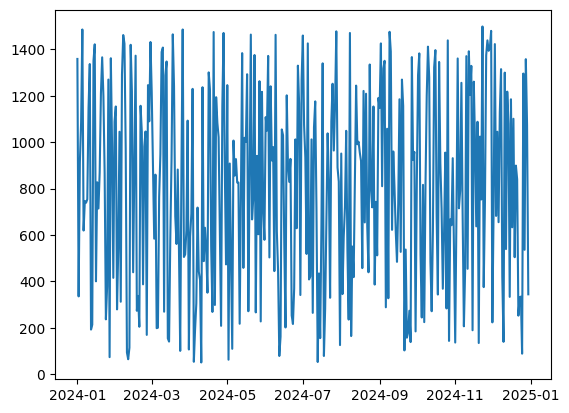

In [ ]:

# Daily Cases Trend
import matplotlib.pyplot as plt
plt.plot(df['Date'], df['Daily_Cases'])

In [ ]:
import os
output_dir = 'visualizations'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig('visualizations/daily_cases_trend.png')


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.show()

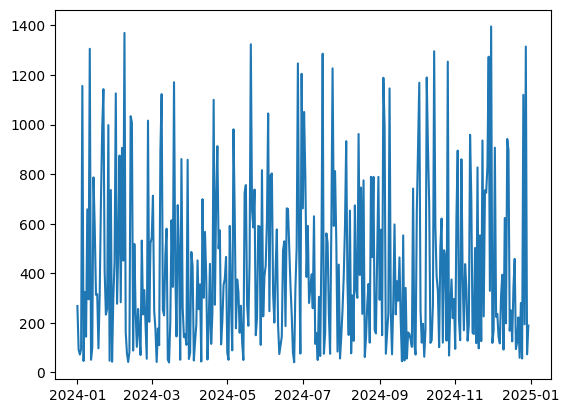

In [ ]:
# Recovery Trend
plt.plot(df['Date'], df['Daily_Recoveries'])

Text(0, 0.5, 'Recoveries')

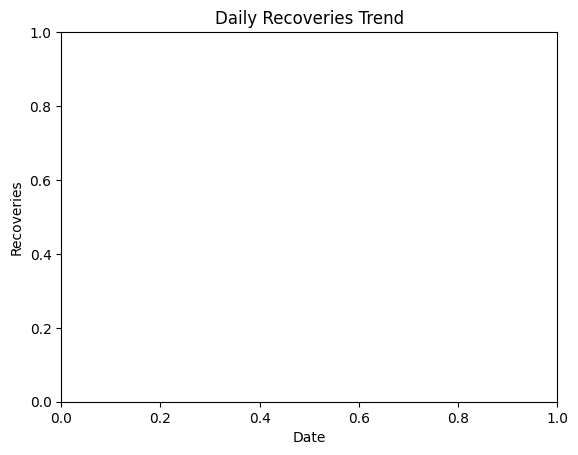

In [ ]:
plt.title("Daily Recoveries Trend")
plt.xlabel("Date")
plt.ylabel("Recoveries")

In [ ]:
plt.savefig('visualizations/daily_cases_trend.png')

plt.show()

<Figure size 640x480 with 0 Axes>

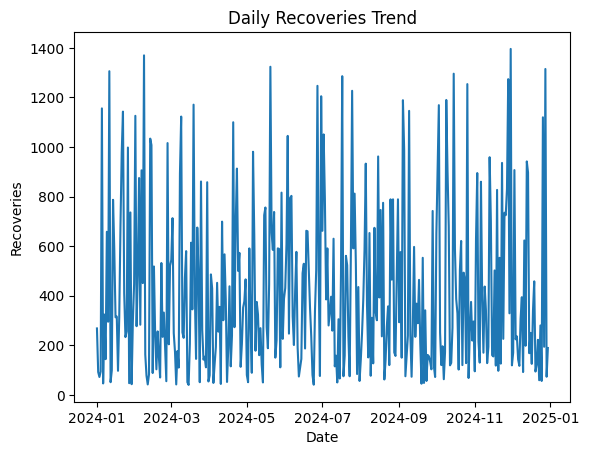

In [ ]:
# Recovery Trend
plt.plot(df['Date'], df['Daily_Recoveries'])

plt.title("Daily Recoveries Trend")
plt.xlabel("Date")
plt.ylabel("Recoveries")

plt.savefig('visualizations/recovery_trend.png')

plt.show()


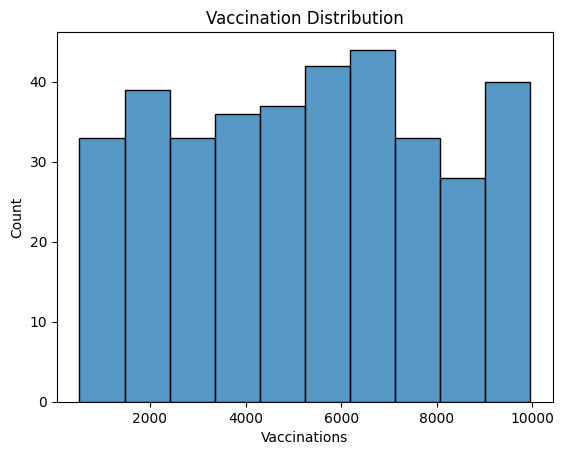

In [ ]:
# Vaccination Distribution
import seaborn as sns
sns.histplot(df['Vaccinations'])

plt.title("Vaccination Distribution")

plt.savefig('visualizations/vaccination_distribution.png')

plt.show()

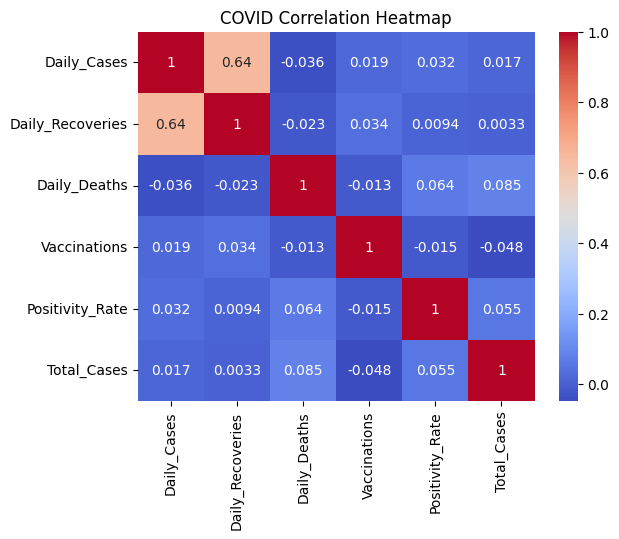

In [ ]:
# Correlation Heatmap
import numpy as np
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("COVID Correlation Heatmap")

plt.savefig('visualizations/correlation_heatmap.png')

plt.show()


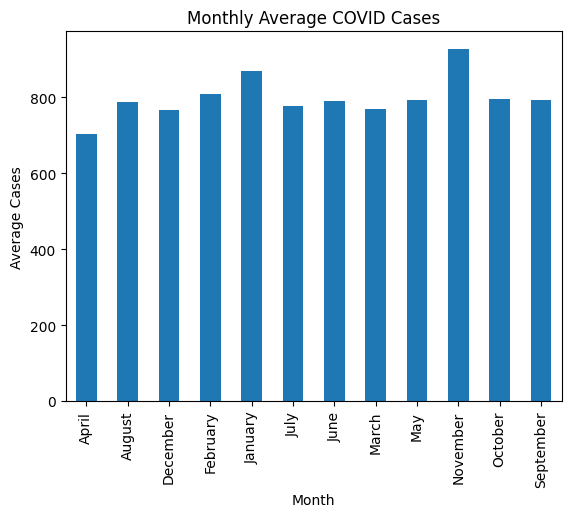

In [ ]:
# Monthly Average Cases
monthly_cases = (
    df.groupby('Month')['Daily_Cases']
    .mean()
)

monthly_cases.plot(kind='bar')

plt.title("Monthly Average COVID Cases")
plt.ylabel("Average Cases")

plt.savefig('visualizations/monthly_cases.png')

plt.show()

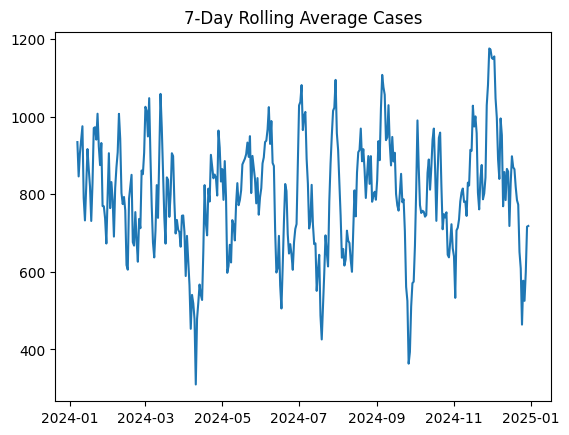

In [ ]:
# Rolling Average
df['7_Day_Avg'] = (
    df['Daily_Cases']
    .rolling(7)
    .mean()
)

plt.plot(df['Date'], df['7_Day_Avg'])

plt.title("7-Day Rolling Average Cases")

plt.savefig('visualizations/rolling_average.png')

plt.show()

In [ ]:
# Key Metrics
total_cases = df['Daily_Cases'].sum()
total_recoveries = df['Daily_Recoveries'].sum()
total_deaths = df['Daily_Deaths'].sum()

recovery_rate = (
    total_recoveries / total_cases
) * 100

death_rate = (
    total_deaths / total_cases
) * 100

In [ ]:
print("Total Cases:", total_cases)
print("Total Recoveries:", total_recoveries)
print("Total Deaths:", total_deaths)

print("Recovery Rate:", round(recovery_rate,2))
print("Death Rate:", round(death_rate,2))

Total Cases: 291447
Total Recoveries: 152550
Total Deaths: 9761
Recovery Rate: 52.34
Death Rate: 3.35


In [ ]:
# Generate Report
report = f"""
COVID HEALTHCARE ANALYSIS REPORT
================================

Total Cases: {total_cases}

Total Recoveries: {total_recoveries}

Total Deaths: {total_deaths}

Recovery Rate: {round(recovery_rate,2)}%

Death Rate: {round(death_rate,2)}%+"""

In [ ]:
import os

# Create the reports directory if it doesn't exist
reports_dir = 'reports'
if not os.path.exists(reports_dir):
    os.makedirs(reports_dir)

with open(
    os.path.join(reports_dir, 'covid_report.txt'),
    'w'
) as file:

    file.write(report)

print("Healthcare report generated successfully!")

Healthcare report generated successfully!
